<a href="https://colab.research.google.com/github/Finvaly996/KuperCalls/blob/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%81%D0%B2%D1%8F%D0%B7%D0%B8_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B0%D0%BF%D1%81%D0%B5%D0%B9%D0%BB%D0%B0_%D0%B8_%D0%BF%D0%BE%D0%BA%D0%B0%D0%B7%D0%B0%D1%82%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B7%D0%B2%D0%BE%D0%BD%D0%BA%D0%BE%D0%B2_%D0%B8_%D1%81%D0%BA%D0%BE%D1%80%D0%BE%D1%81%D1%82%D0%B8_%D1%81%D0%B1%D0%BE%D1%80%D1%89%D0%B8%D0%BA%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорты и настройки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files

# Введение и ТЗ

##Центральная бизнес-ситуация (контекст)

В начале 2026 года руководство компании «X» ужесточило контроль за выполнением скрипта звонков: сборщики обязаны предлагать клиентам дополнительные товары (апсейл) с целевым показателем в 33% от всех успешных звонков. Это было негативно воспринято сборщиками: выполнение регламента по апсейлу негативно влияет на скорость сборки заказов, основной фактор их дохода. Возник конфликт метрик: Качество звонков (Upsell / апсейл) vs Скорость сборки.

## Цель исследования:
На основе реальных данных рабочей точки я поставил цель оценить фактический масштаб выполнения KPI по апсейлу, исследовать его влияние на метрики скорости сборки и качества звонков и выявить паттерны поведения сотрудников для поиска баланса между скоростью и качеством сервиса.

## Задачи и гипотезы исследования:

1. **Расчет базовых метрик:** Вычислить фактический % апсейла по точке и его распределение среди сборщиков.
  * *Гипотеза 1:* Медианный и средний процент выполнения целевого показателя по апсейлу находится ниже установленного порога в 33%.

2. **Корреляционный анализ:** Оценить связь между метриками качества звонков (особенно процентом апсейла) и скоростью сборки.
  * *Гипотеза 2:* Существует обратная связь между качеством звонков и скоростью сборки. Быстрые сборщики жертвуют качеством (апсейлом, частотой звонков) ради оплачиваемого попадания в таймер (снижают «Время уточнения»).

3. **Корреляционный анализ:** Оценить наличие связи между процентом апсейла и другими метриками звонка
  * *Гипотеза 3:* Сборщики с высоким процентом апсейла имеют высокие показатели по другим показателям звонков (комплексный подход к качеству).

4. **Когортный анализ сотрудников:** Сравнить показатели сборщиков с разной интенсивностью работы (разделить на когорты «ветеранов» и «новичков» по количеству выполненных заказов).
  * *Гипотеза 4:* Процент апсейла ниже у сотрудников с большим количеством заказов («ветеранов»), так как они привыкли к старым регламентам и приоритизируют скорость.

5. **Сегментация:** Разделить сборщиков на группы по соотношению «качество/скорость» для выявления паттернов оптимальной работы.
  * *Ожидаемый результат:* Несколько классов, отражающих особенности поведения сборщиков, с четко обозначенными преимуществами и зонами роста.

## Описание данных:
Исследование проводится на основе датасетов «Время сборки в разрезах». и «Статистика созвонов» на одной конкретной торговой точке. В результате анонимизации эти датасеты были слиты в два новых датасета - `«speed»` и `«calls»`
### Датасет `«speed»`. Каждая строка - усредненный либо суммированный показатель отдельного сборщика за неделю по показателям скорости. Минимальная дата – 28 декабря 2025 года, максимальная – 25 февраля 2026 (текущая дата на момент исследования). Всего приведены данные за 9 недель.
###Список переменных:
-	`Категория 1` - обезличенный ID сборщика
-	`min_date` и `max_date` – минимальная и максимальная дата работы на той или иной неделе
-	`Время от начала сборки до добавления первой позиции, мин` (здесь и дальше- усредненные показатели по всей неделе)
-	`Время сборки позиций, мин` - средний показатель в минутах для каждого заказа
-	`Время уточнения, мин` - средний показатель в минутах для каждого заказа
-	`Время оплаты, мин` - средний показатель в минутах для каждого заказа
-	`Время упаковки, мин` - средний показатель в минутах для каждого заказа
-	`Время оплаты + упаковки, мин` - средний показатель в минутах для каждого заказа
-	`Общее время сборки, мин` - средний показатель в минутах для каждого заказа (средняя суммарная длительность всей сборки от принятия до завершения заказа)
-	`Время на паузах, мин` - среднее время постановки заказа на паузу за неделю
- `Время приостановки, мин` - трудноинтерпретируемая техническая переменная
-	`Скорость сборки общая` - общее время сборки / количество товаров в заказе
-	`Количество заказов` (сколько всего заказов было собрано в течение недели)

### Датасет `«calls»`. По каждому сборщику содержит разделенную по неделям информацию с показателями качества звонков клиентам. Данные доступны за временной период от 25 августа 2025 года до 25 февраля 2026 года.
### Список переменных: (все данные приводятся в процентном формате от общего числа звонков сборщика за неделю, кроме тех, о которых это оговорено отдельно)
- `Category 1`: обезличенный ID сборщика
- `Дата` (начало недели, в которую проводился замер) (формат dd.mm.yy)
- `Звонка не было, %`
- `Звонка не было`  (цельночисленный формат – количество отсутствий попыток звонка клиенту за соответствующую неделю)
- `Клиент не взял трубку, %`
- `Успешное соединение` (цельночисленный формат – количество успешных звонков клиенту, т.е. вызов прошел и разговор состоялся)
- `Успешное соединение, %`
- `Кoл-во заказов` (цельночисленный формат – сколько всего заказов собрал сборщик за соответствующую неделю)
- `Кол-во попыток звонка` (цельночисленный формат –за соответствующую неделю)
- `Длительность звонка (разговор)` (цельночисленный формат – суммарная длительность в минутах за соответствующую неделю)
- `% дозвона` - доля дозвона от всех звонков сборщика за неделю.
- `% отправок событий о звонке <5 мин` - трудноинтерпретируемая техническая переменная
- `Коммуникационные ошибки` (отображает процент отступлений от регламента в целом)
- `Предложил корректно замену`
- `Сообщил об отсутствии, не предложил замену и задал вопрос` - доля от всех успешных звонков за неделю
- `Сообщил об отсутствии и не предложил замену`- доля от всех успешных звонков за неделю
- `Сразу предложил отмену` - доля от всех успешных звонков за неделю
- `Несодержательный диалог` - доля от всех успешных звонков за неделю (в какой части звонков присутствовал диалог, не связанный с обсуждением замен)
- `Уточнение параметров товара`
- `Диалог не про товары` - доля от всех успешных звонков за неделю (в какой части звонков присутствовал диалог на посторонние темы)
- `% апсейла` (предложений о добавлении товаров к заказу при звонке) от всех успешных звонков. Центральная переменная исследования, распределенная от 0 до 1.


##Формат выводов


*   Дашборд Tableau;
*   Readme-файл выводами;
*   Код с комментариями в Markdown

**!!Для обеспечения безопасности ФИО всех сборщиков были заменены на псевдонимы / номера по итогу объединения таблиц!!**

# Чтение данных

In [2]:
url_speed = 'https://github.com/Finvaly996/KuperCalls/raw/main/speed.xlsx'
speed = pd.read_excel(url_speed)
speed.head()

,Категория 1,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты, мин","Время упаковки, мин","Время оплаты + упаковки, мин","Общее время сборки, мин","Время на паузах, мин","Время приостановки, мин",Скорость сборки общая,Скорость сборки (param),Изначальная корзина,Количество заказов
0,Сборщик 557,24.01.2026,25.01.2026,2.672000,16.838333,0.550294,3.595139,2.977778,6.572917,26.426870,0.000000,0.0,1.491358,1.173890,17.720000,25
1,Сборщик 54,20.01.2026,25.01.2026,5.469565,20.106522,0.327536,2.370290,4.963768,7.334058,33.237681,0.000000,0.0,2.060557,1.605885,16.130435,23
2,Сборщик 535,19.01.2026,24.01.2026,5.220370,42.166667,0.959259,4.424074,3.225926,7.650000,55.996296,0.000000,0.0,3.705637,3.199387,15.111111,9
3,Сборщик 458,20.01.2026,24.01.2026,0.899550,30.344144,0.863964,2.021622,3.190991,5.212613,37.320270,6.191441,0.0,1.205983,1.037540,30.945946,37
4,Сборщик 39,19.01.2026,23.01.2026,3.273249,35.201075,0.330645,3.472581,5.537634,9.010215,47.815741,0.000000,0.0,2.239106,1.817151,21.354839,31


In [3]:
url_calls = 'https://github.com/Finvaly996/KuperCalls/raw/main/calls.xlsx'
calls = pd.read_excel(url_calls)
calls.head()

,Category 1,Дата,"Звонка не было, %","Клиент не взял трубку, %","Успешное соединение, %",Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),...,Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,Без класса,% апсейла от всех успешных звонков
0,Сборщик 106,25.08.25,0.060000,0.200000,0.740000,50,37,3,61,54.533333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,01.09.25,0.200000,0.333333,0.466667,15,7,3,15,7.600000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,15.09.25,0.066667,0.200000,0.733333,30,22,2,32,24.116667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,22.09.25,0.100000,0.150000,0.750000,40,30,4,43,41.050000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,29.09.25,0.063830,0.191489,0.744681,47,35,3,55,43.050000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Предобработка данных - исходные датасеты





Оба датасета содержат показатели одних и тех же сборщиков, разделенные по неделям. Таким образом, после обзора и работы с NaN и аномалиями, преобразования типов и переменных оба датасета преобразованы в сгруппированные датасеты по каждому сборщику.

Общая информация о переменных:

In [4]:
speed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 16 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Категория 1                                               582 non-null    object 
 1   min date                                                  582 non-null    object 
 2   max date                                                  582 non-null    object 
 3   Время от начала сборки до добавления первой позиции, мин  582 non-null    float64
 4   Время сборки позиций, мин                                 582 non-null    float64
 5   Время уточнения, мин                                      582 non-null    float64
 6   Время оплаты, мин                                         582 non-null    float64
 7   Время упаковки, мин                                       582 non-null    float64
 8   Время оплаты + упако

In [5]:
speed.describe()

,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты, мин","Время упаковки, мин","Время оплаты + упаковки, мин","Общее время сборки, мин","Время на паузах, мин","Время приостановки, мин",Скорость сборки общая,Скорость сборки (param),Изначальная корзина,Количество заказов
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,4.577860,30.862275,0.987918,3.976894,4.955970,8.932864,45.317042,5.289556,0.000039,2.565406,2.066020,19.036490,24.606529
std,3.573480,15.021178,0.954156,6.039609,2.055997,6.481291,19.950452,31.783740,0.000265,1.348108,1.084733,6.374455,22.015051
min,0.375845,5.931667,0.044444,1.057576,1.423264,3.691667,18.799969,0.000000,0.000000,0.887680,0.702119,3.750000,3.000000
25%,2.678887,20.664476,0.395705,2.240913,3.722384,6.344242,32.165645,0.000000,0.000000,1.690432,1.336550,15.334507,8.000000
50%,3.749442,27.081410,0.685924,2.891667,4.467468,7.634211,39.867934,0.000000,0.000000,2.243245,1.772738,18.397917,17.000000
75%,5.449761,37.209259,1.237083,3.928977,5.669151,9.507197,52.633594,0.000000,0.000000,2.992566,2.444483,21.587302,36.000000
max,40.554310,117.545833,8.966667,100.059259,17.250000,103.711111,154.035185,285.690196,0.002721,14.967098,7.752011,65.571429,130.000000



Необходимые изменения в датасете `speed`:
- Очистка данных от дублирующих / незначительных переменных;
- Изменение типа переменных минимальной и максимальной даты и переименование (для унификации).
- Некоторые значения однозначно аномальны - например, оплата в 100 минут или время на паузах в 285 минут. Хотя это объяснимо спецификой рабочей деятельности (сборщики ждут устранения технических проблем с оплатой заказа / собирают заказы по очереди, откуда и берутся 40 минут до первой позиции), эти аномалии способны повлиять на финальные выводы.

В данной таблице нет пропусков, однако возможны аномальные значения.

In [6]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2323 entries, 0 to 2322
Data columns (total 22 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Category 1                                                 852 non-null    object 
 1   Дата                                                       2323 non-null   object 
 2   Звонка не было, %                                          2033 non-null   float64
 3   Клиент не взял трубку, %                                   2033 non-null   float64
 4   Успешное соединение, %                                     2033 non-null   float64
 5   Кoл-во заказов                                             2323 non-null   int64  
 6   Успешное соединение                                        2323 non-null   int64  
 7   Звонка не было                                             2323 non-null   int64  
 8   Кол-во п

In [7]:
calls.describe()

,"Звонка не было, %","Клиент не взял трубку, %","Успешное соединение, %",Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),% дозвона,% отправок событий о звонке <5 мин,Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,Без класса,% апсейла от всех успешных звонков
count,2033.000000,2033.000000,2033.000000,2323.000000,2323.000000,2323.000000,2323.000000,1910.000000,1855.000000,1910.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.0,1207.000000
mean,0.191090,0.077086,0.731823,16.589755,12.293586,2.526044,21.188119,19.361117,0.901041,0.946215,0.426962,0.460813,0.212378,0.204579,0.010006,0.019559,0.074661,0.018005,0.0,0.074878
std,0.311311,0.164871,0.331866,399.737689,296.233268,60.912962,510.572291,423.005013,0.195466,0.154776,0.347628,0.342513,0.282512,0.285560,0.068467,0.085264,0.154502,0.079444,0.0,0.196015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,0.000000,0.000000,0.600000,1.000000,1.000000,0.000000,1.000000,1.887500,0.881176,1.000000,0.117647,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,0.000000,0.000000,0.864865,5.000000,3.000000,0.000000,5.000000,5.416667,1.000000,1.000000,0.375000,0.500000,0.090909,0.062500,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
75%,0.250000,0.090909,1.000000,12.000000,9.000000,1.000000,15.000000,12.833333,1.000000,1.000000,0.666667,0.700000,0.333333,0.333333,0.000000,0.000000,0.100000,0.000000,0.0,0.000000
max,1.000000,1.000000,1.000000,19269.000000,14279.000000,2934.000000,24610.000000,18489.866667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.666667


Необходимые изменения в датасете `calls`:
- Обработка пропусков, в первую очередь - в центральной переменной % апсейла и ID сборщика;
- Очистка данных от дублирующих / незначительных / трудно интерпретируемых переменных;
- Изменение типа переменных даты;
- Переименование переменной с ID сборщика;
- Работа с аномалиями в данном датасете - приоритет: например, 24 тысячи попыток звонка и 19 тысяч заказов явно сдвигают распределение переменных.

Важно! Максимальные значения центральной переменной `% апсейла от всех успешных звонков`- аномальны. При ближайшем рассмотрении оказалось, что это три строки - процент превышает 100. Чтобы не потерять важные данные по другим показателям, данные по проценту апсейла для них заменены на NaN.

In [8]:
calls.sort_values(by='% апсейла от всех успешных звонков', ascending=False).head()

,Category 1,Дата,"Звонка не было, %","Клиент не взял трубку, %","Успешное соединение, %",Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),...,Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,Без класса,% апсейла от всех успешных звонков
465,NaN,27.10.25,0.000000,0.100000,0.90000,10,9,0,21,10.800000,...,0.666667,0.333333,0.0,0.666667,0.0,0.0,0.0,0.0,0.0,1.666667
75,NaN,02.02.26,0.347826,0.391304,0.26087,23,6,8,16,7.916667,...,0.500000,0.000000,0.0,0.500000,0.0,0.0,0.0,0.5,0.0,1.500000
145,NaN,29.12.25,0.000000,0.000000,1.00000,3,3,0,3,4.250000,...,0.000000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.500000
1918,Сборщик 235,22.12.25,0.000000,0.000000,1.00000,1,1,0,1,1.383333,...,1.000000,0.000000,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000
1756,Сборщик 776,09.02.26,0.000000,0.000000,1.00000,2,2,0,4,3.416667,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,1.000000


In [9]:
calls.loc[calls['% апсейла от всех успешных звонков'] > 1, '% апсейла от всех успешных звонков'] = np.nan

#уточнение про NaNы - потому что в противном случае они отфильтруются автоматически
calls.sort_values(by='% апсейла от всех успешных звонков', ascending=False).head()

,Category 1,Дата,"Звонка не было, %","Клиент не взял трубку, %","Успешное соединение, %",Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),...,Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,Без класса,% апсейла от всех успешных звонков
2010,Сборщик 777,02.02.26,0.0,0.0,1.0,1,1,0,1,1.166667,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2002,Сборщик 277,12.01.26,0.0,0.0,1.0,1,1,0,1,4.650000,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1918,Сборщик 235,22.12.25,0.0,0.0,1.0,1,1,0,1,1.383333,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1756,Сборщик 776,09.02.26,0.0,0.0,1.0,2,2,0,4,3.416667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1572,NaN,10.11.25,0.0,0.0,1.0,1,1,0,1,1.500000,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## Трансформация и очистка переменных

### Удаление ненужных переменных

**В датасете `speed`:**

`Скорость сборки (param)` - дублирует переменную `Скорость сборки общая`

`Время приостановки, мин` - трудноинтерпретируемая переменная, мало связанная с показателем апсейла. Кроме того, паузы и приостановки на практике часто связаны с внешними причинами, например, неполадками в приложении. Избежать их влияние на основную переменную скорости сборки не представляется возможным, но саму переменную `Время на паузах, мин` также считаю необходимым удалить;

`Время оплаты, мин` и `Время упаковки, мин` - собраны в комплексную переменную
Время оплаты + упаковки, мин. Может быть интересно изучить особенности оплаты и упаковки, однако эти этапы происходят после звонков (и апсейла) и не связаны напрямую с задачами исследования;

`Изначальная корзина` - также переменная, от которой придётся избавиться в силу трудноинтерпретируемости. Она неявно дублирует `Скорость сборки, общая` и `Время сборки позиций, мин` - избавимся от нее, чтобы избежать мультиколлинеарности.

**В датасете `calls`:**

Большинство переменных в датасете calls нужны в рамках задачи о сравнении показателей апсейла и других метрик качества звонков. Удалить придётся следующие:

`Клиент не взял трубку, %`, `Успешное соединение, %`, `% дозвона` - никак не зависят от качества работы сборщика;

`% отправок событий о звонке <5 мин`, `Без класса` - трудноинтерпретируемые переменные;

`Звонка не было, %` - дублирует информацию из `Звонка не было`, будет потеряна при агрегации, удобнее будет посчитать позднее при необходимости

In [10]:
speed = speed.drop(columns=['Скорость сборки (param)',
                            'Время приостановки, мин',
                            'Время на паузах, мин',
                            'Время оплаты, мин',
                            'Время упаковки, мин',
                            'Изначальная корзина'])
speed.head()

,Категория 1,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты + упаковки, мин","Общее время сборки, мин",Скорость сборки общая,Количество заказов
0,Сборщик 557,24.01.2026,25.01.2026,2.672000,16.838333,0.550294,6.572917,26.426870,1.491358,25
1,Сборщик 54,20.01.2026,25.01.2026,5.469565,20.106522,0.327536,7.334058,33.237681,2.060557,23
2,Сборщик 535,19.01.2026,24.01.2026,5.220370,42.166667,0.959259,7.650000,55.996296,3.705637,9
3,Сборщик 458,20.01.2026,24.01.2026,0.899550,30.344144,0.863964,5.212613,37.320270,1.205983,37
4,Сборщик 39,19.01.2026,23.01.2026,3.273249,35.201075,0.330645,9.010215,47.815741,2.239106,31


In [11]:
calls = calls.drop(columns=['Клиент не взял трубку, %',
                            'Успешное соединение, %',
                            '% дозвона',
                            '% отправок событий о звонке <5 мин',
                            'Без класса',
                            'Звонка не было, %'])
calls.head()

,Category 1,Дата,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков
0,Сборщик 106,25.08.25,50,37,3,61,54.533333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,01.09.25,15,7,3,15,7.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,15.09.25,30,22,2,32,24.116667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,22.09.25,40,30,4,43,41.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,29.09.25,47,35,3,55,43.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Проверка на дубликаты

In [12]:
speed.duplicated().sum()

np.int64(0)

In [13]:
calls.duplicated().sum()

np.int64(32)

In [14]:
calls[calls.duplicated(keep=False)].sort_values(by='Дата').head(15)

,Category 1,Дата,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков
1409,NaN,01.12.25,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1284,NaN,01.12.25,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
602,NaN,01.12.25,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
693,NaN,01.12.25,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1519,NaN,01.12.25,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1244,NaN,01.12.25,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1203,NaN,01.12.25,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1317,NaN,01.12.25,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1461,NaN,03.11.25,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1800,NaN,03.11.25,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Дубликатов в датасете `speed` не обнаружено. Дубликаты в `calls` есть, но до заполнения пропусков в ID сборщика нельзя сказать, относятся ли они к одному и тому же или разным сборщикам.

## Изменение типов переменных + переименование

In [15]:
speed = speed.rename(columns={'Категория 1' : 'ID сборщика'})
speed['min date'] = pd.to_datetime(speed['min date'], dayfirst=True)
speed['max date'] = pd.to_datetime(speed['max date'], dayfirst=True)
speed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 10 columns):
 #   Column                                                    Non-Null Count  Dtype         
---  ------                                                    --------------  -----         
 0   ID сборщика                                               582 non-null    object        
 1   min date                                                  582 non-null    datetime64[ns]
 2   max date                                                  582 non-null    datetime64[ns]
 3   Время от начала сборки до добавления первой позиции, мин  582 non-null    float64       
 4   Время сборки позиций, мин                                 582 non-null    float64       
 5   Время уточнения, мин                                      582 non-null    float64       
 6   Время оплаты + упаковки, мин                              582 non-null    float64       
 7   Общее время сборки, мин                     

In [16]:
calls = calls.rename(columns={'Category 1' : 'ID сборщика'})
calls[calls['Дата'] == 'Total']

,ID сборщика,Дата,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков
2322,Сборщик 555,Total,19269,14279,2934,24610,18489.866667,0.402105,0.461089,0.186436,0.206964,0.008705,0.019488,0.101078,0.01624,0.11459


Последняя строка оказалась строкой со значением даты равным 'Total'. Это строка с саммари исходного датасета - она была удалена, а переменная с датой приведена к нужному типу. Заодно устранена основная аномалия в датасете.

In [17]:
calls = calls[calls['Дата'] != 'Total']
calls['Дата'] = pd.to_datetime(calls['Дата'], dayfirst=True)
calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2322 entries, 0 to 2321
Data columns (total 16 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   ID сборщика                                                851 non-null    object        
 1   Дата                                                       2322 non-null   datetime64[ns]
 2   Кoл-во заказов                                             2322 non-null   int64         
 3   Успешное соединение                                        2322 non-null   int64         
 4   Звонка не было                                             2322 non-null   int64         
 5   Кол-во попыток звонка                                      2322 non-null   int64         
 6   Длительность звонка (разговор)                             1909 non-null   float64       
 7   Коммуникационные ошибки               

/tmp/ipykernel_5963/1256703909.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  calls['Дата'] = pd.to_datetime(calls['Дата'], dayfirst=True)


### Важное уточнение!

Обычно не несущие информации или аномальные данные очищаются на этапе работы с пропусками и обработки аномалий. Однако текущие данные `speed` `calls` приведены понедельно - впоследствии, для оценки показателей по сборщикам, они агрегируются по каждому сборщику за все время. Таким образом, предобработка данных разбита на два этапа - до и после группировки, причем основная фильтрация - после группировки.

## Работа с пропусками

Пропуски есть в датасете `calls`. Во-первых, необходимо заполнить пропуски в `ID сборщика`, "растянув" значения вниз до следующего значения.

In [18]:
# заполнение пропусков в номере сборщика предыдущими значениями
calls['ID сборщика'] = calls['ID сборщика'].ffill()
display(calls['ID сборщика'].isna().sum())

np.int64(0)

In [19]:
calls[calls.duplicated(keep=False)].sort_values(by='Дата')

,ID сборщика,Дата,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков


"Растягивание" ID сборщика устранило дубликаты в данных.

В половине переменных, начиная с `Коммуникационные ошибки`, равное количество пропусков. Осмотр данных дает понять, что эти пропуски всегда идут рука об руку:

In [20]:
calls[calls['Коммуникационные ошибки'].isna()].head()

,ID сборщика,Дата,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков
0,Сборщик 106,2025-08-25,50,37,3,61,54.533333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Сборщик 106,2025-09-01,15,7,3,15,7.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Сборщик 106,2025-09-15,30,22,2,32,24.116667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Сборщик 106,2025-09-22,40,30,4,43,41.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Сборщик 106,2025-09-29,47,35,3,55,43.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
calls[calls['Коммуникационные ошибки'].isna() == False].head()

,ID сборщика,Дата,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков
8,Сборщик 106,2025-10-27,47,32,0,63,33.200000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.500000
9,Сборщик 106,2025-11-03,48,37,0,68,38.783333,0.111111,0.740741,0.037037,0.074074,0.000000,0.037037,0.111111,0.00,0.185185
10,Сборщик 106,2025-11-10,36,31,2,43,29.600000,0.130435,0.739130,0.043478,0.043478,0.043478,0.000000,0.130435,0.00,0.173913
11,Сборщик 106,2025-11-17,37,32,0,46,34.333333,0.160000,0.760000,0.040000,0.080000,0.040000,0.000000,0.040000,0.04,0.120000
12,Сборщик 106,2025-11-24,51,38,3,60,39.766667,0.133333,0.800000,0.066667,0.066667,0.000000,0.000000,0.066667,0.00,0.000000


У одного и того же сборщика значения пропущены в первых строках и отсутствуют в остальных. Дело в дате - до недели с 27.10 эти данные не вносились, да и для недели 27.10 отсутствуют во многих случаях. Таким образом, это не аномальные значения, а пропуски, обусловленные спецификой данных, их заполнение невозможно.

<Axes: xlabel='Дата'>

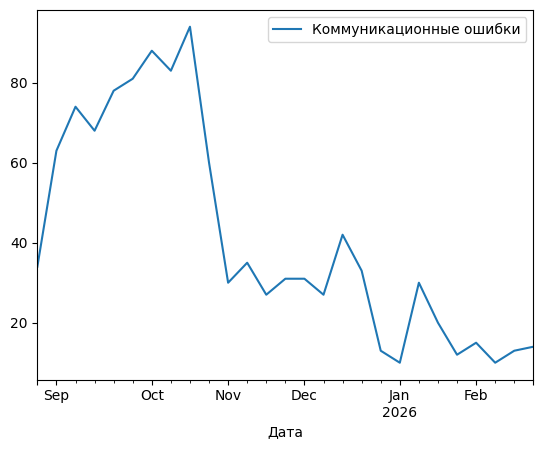

In [22]:
calls['Коммуникационные ошибки'].isna().groupby(calls['Дата']).sum().reset_index().sort_values('Дата').plot(
    x='Дата',
    y='Коммуникационные ошибки')

С введением подсчета количество пропусков существенно сокращается, но все же остается. Также пропуски связаны с отсутствием заказов в конкретную неделю:

In [23]:
calls[(calls['Коммуникационные ошибки'].isna()) & (calls['Кoл-во заказов'] == 0)].head()

,ID сборщика,Дата,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков
462,Сборщик 272,2025-10-06,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
512,Сборщик 623,2025-12-29,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
569,Сборщик 153,2026-01-19,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
598,Сборщик 54,2025-11-03,0,0,0,1,0.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
693,Сборщик 491,2025-12-01,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Строки с отсутствующими заказами было решено удалить вообще - они не несут никакой информации, не влияют на показатели при группировке, а в строке для недели от 3 ноября для сборщика 54 показывают невозможные данные.

In [24]:
calls_copy = calls.copy() #вспомогательная переменная, фиксирующая значения до фильтрации
speed_copy = speed.copy() #вспомогательная переменная, фиксирующая значения до фильтрации

In [25]:
calls= calls[calls['Кoл-во заказов'] > 0]
calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2032 entries, 0 to 2114
Data columns (total 16 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   ID сборщика                                                2032 non-null   object        
 1   Дата                                                       2032 non-null   datetime64[ns]
 2   Кoл-во заказов                                             2032 non-null   int64         
 3   Успешное соединение                                        2032 non-null   int64         
 4   Звонка не было                                             2032 non-null   int64         
 5   Кол-во попыток звонка                                      2032 non-null   int64         
 6   Длительность звонка (разговор)                             1862 non-null   float64       
 7   Коммуникационные ошибки               

Оставшиеся строки с пропусками в коммуникационных ошибках имеют низкие показатели в статистике "Успешное соединение". Вероятно, система не включает в подсчет недели, по которым для сборщика нельзя посчитать корректную статистику.

In [26]:
cutoff_date = pd.Timestamp('2025-10-27')
calls[(calls['Коммуникационные ошибки'].isna()) & (calls['Дата'] > cutoff_date)]['Успешное соединение'].unique()

array([0, 1, 2, 3])

Причина пропусков в переменных, связанных с детализацией качества звонков, найдена - либо отсутствие фиксации до 27.10.25, либо недостаточные данные по  конкретной неделе. Было решено **удалить** строки с датой до начала измерений и недостаточными данными - они могут искажать статистику сборщиков по другим неделям.

In [27]:
calls = calls[calls['Коммуникационные ошибки'].isna() == False]
calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1206 entries, 8 to 2112
Data columns (total 16 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   ID сборщика                                                1206 non-null   object        
 1   Дата                                                       1206 non-null   datetime64[ns]
 2   Кoл-во заказов                                             1206 non-null   int64         
 3   Успешное соединение                                        1206 non-null   int64         
 4   Звонка не было                                             1206 non-null   int64         
 5   Кол-во попыток звонка                                      1206 non-null   int64         
 6   Длительность звонка (разговор)                             1206 non-null   float64       
 7   Коммуникационные ошибки               

К сожалению, данные за первые месяцы изучения оказались малоинформативны, но на этом работу с пропусками можно считать завершенной.

## Агрегация показателей по неделям



И в датасете `calls`, и в датасете `speed` собраны еженедельные срезы. Для решения задач исследования необходима агрегация по сборщику за все время.

Логика агрегации:


1. Абсолютные метрики (`Время сборки позиций, мин`, `Успешное соединение`) агрегированы методом суммы.

2. Относительные метрики (`Уточнение параметров товара`, `Скорость сборки общая`) рассчитаны через взвешенное среднее, чтобы избежать статистического искажения (подсчет среднего средних).


В качестве весов для показателей скорости использовалась переменная `Количество заказов`.


In [28]:
avg_columns = [
    'Время от начала сборки до добавления первой позиции, мин',
    'Время сборки позиций, мин',
    'Время уточнения, мин',
    'Время оплаты + упаковки, мин',
    'Общее время сборки, мин',
    'Скорость сборки общая'
]

speed_temp = speed.copy()

# Логика агрегации: каждая переменная умножена на вес (количество заказов),
# чтобы получить сумму за неделю, а на этапе группировки разделена заново
for col in avg_columns:
    speed_temp[f'{col}_sum'] = speed_temp[col] * speed_temp['Количество заказов']

# Словарь с правилами группировки - понадобится для разделения абсолютных и относительных переменных
agg_rules = {
    'Количество заказов': 'sum',
    'min date': 'min', #даты оставлены "на всякий случай"
    'max date': 'max'
}

for col in avg_columns:
    agg_rules[f'{col}_sum'] = 'sum'

speed_w = speed_temp.groupby('ID сборщика').agg(agg_rules).reset_index()

#взвешивание относительных данных
for col in avg_columns:
    speed_w[col] = speed_w[f'{col}_sum'] / speed_w['Количество заказов']
    speed_w = speed_w.drop(columns=[f'{col}_sum'])

speed_w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 10 columns):
 #   Column                                                    Non-Null Count  Dtype         
---  ------                                                    --------------  -----         
 0   ID сборщика                                               161 non-null    object        
 1   Количество заказов                                        161 non-null    int64         
 2   min date                                                  161 non-null    datetime64[ns]
 3   max date                                                  161 non-null    datetime64[ns]
 4   Время от начала сборки до добавления первой позиции, мин  161 non-null    float64       
 5   Время сборки позиций, мин                                 161 non-null    float64       
 6   Время уточнения, мин                                      161 non-null    float64       
 7   Время оплаты + упаковки, мин                

In [29]:
speed_w.head()

,ID сборщика,Количество заказов,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты + упаковки, мин","Общее время сборки, мин",Скорость сборки общая
0,Сборщик 102,16,2026-01-06,2026-01-10,6.787500,52.009375,1.360417,7.191667,67.348958,3.991049
1,Сборщик 106,770,2025-12-28,2026-02-23,1.888636,14.566335,1.101477,4.942178,22.494519,1.227740
2,Сборщик 108,11,2026-01-14,2026-01-29,11.975758,31.890909,1.840909,8.971212,54.678788,4.419908
3,Сборщик 112,3,2026-02-21,2026-02-21,7.561111,56.672222,2.333333,24.894444,91.461111,5.380065
4,Сборщик 116,4,2026-01-23,2026-01-24,11.395833,58.816667,0.712500,11.366667,82.291667,7.655039


Агрегация для датасета `speed` прошла успешно - количество заказов суммировано, остальные показатели - средние за все время.


В датасете `calls` относительные переменные имеет смысл взвешивать от количества успешных соединений, поскольку необходимость звонка связана с отсутствием товара, а не качеством работы сборщика (или, по крайней мере, истинную причину практически невозможно отследить).

**Важный нюанс!**
Данные, полученные методом агрегации, в дальнейшем проходят слияние с параметрами скорости. Но данные скорости доступны только с 28.12.2025, а данные по звонкам - с конца октября. Если агрегировать все данные звонков, по ним не получится решать задачи о связи с показателями скорости. Решение: отдельный агрегированный датасет, отфильтрованный по дате `calls_wint` - для слияния с `speed`. А также агрегированный датасет для звонков `calls_w` - он необходим для подсчета связей внутри датасета со звонками. Поскольку механика для агрегации этих двух датасетов схожа, она проведена с помощью функции.


In [30]:
avg_cols = [
    'Коммуникационные ошибки',
    'Предложил корректно замену',
    'Сообщил об отсутствии, не предложил замену и задал вопрос',
    'Сообщил об отсутствии и не предложил замену',
    'Сразу предложил отмену',
    'Несодержательный диалог',
    'Уточнение параметров товара',
    'Диалог не про товары',
    '% апсейла от всех успешных звонков'
]

cols_to_sum = [
    'Кoл-во заказов',
    'Успешное соединение',
    'Звонка не было',
    'Кол-во попыток звонка',
    'Длительность звонка (разговор)'
]
def aggregate_calls(data, sum_cols, avg_cols, weight_col='Успешное соединение'):
    temp = data.copy()

    # числители для взвешенного среднего
    for col in avg_cols:
        temp[f'{col}_sum'] = temp[col] * temp[weight_col]

    #генератор словарей с правилами - все суммировать
    agg_rules = {c: 'sum' for c in sum_cols}
    agg_rules |= {f'{c}_sum': 'sum' for c in avg_cols}

    result = temp.groupby('ID сборщика').agg(agg_rules)

    # поправка на тех, у кого "успешное соединение" равно нулю
    zero_weight_mask = result[weight_col] == 0
    zero_weight_count = zero_weight_mask.sum()

    if zero_weight_count > 0:
        print(f"Найдено {zero_weight_count} сборщиков с нулевым количеством успешных соединений")

    for col in avg_cols:
        result[col] = np.where(
            zero_weight_mask,
            np.nan,
            result[f'{col}_sum'] / result[weight_col]
        )
        result = result.drop(columns=f'{col}_sum')

    return result.reset_index()

calls_w = aggregate_calls(calls, cols_to_sum, avg_cols)
calls_wint = aggregate_calls(calls[calls['Дата'] >= speed['min date'].min()],
                             cols_to_sum, avg_cols)

display(calls_w.info())
calls_wint.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 15 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   ID сборщика                                                364 non-null    object 
 1   Кoл-во заказов                                             364 non-null    int64  
 2   Успешное соединение                                        364 non-null    int64  
 3   Звонка не было                                             364 non-null    int64  
 4   Кол-во попыток звонка                                      364 non-null    int64  
 5   Длительность звонка (разговор)                             364 non-null    float64
 6   Коммуникационные ошибки                                    364 non-null    float64
 7   Предложил корректно замену                                 364 non-null    float64
 8   Сообщил об

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   ID сборщика                                                180 non-null    object 
 1   Кoл-во заказов                                             180 non-null    int64  
 2   Успешное соединение                                        180 non-null    int64  
 3   Звонка не было                                             180 non-null    int64  
 4   Кол-во попыток звонка                                      180 non-null    int64  
 5   Длительность звонка (разговор)                             180 non-null    float64
 6   Коммуникационные ошибки                                    180 non-null    float64
 7   Предложил корректно замену                                 180 non-null    float64
 8   Сообщил об

Датасет `calls`  успешно сгруппирован в два новых датасета - теперь без учета недель. В `calls_wint` в два раза меньше записей, чем в `calls_w`, ввиду разного периода сравнений.

<Axes: >

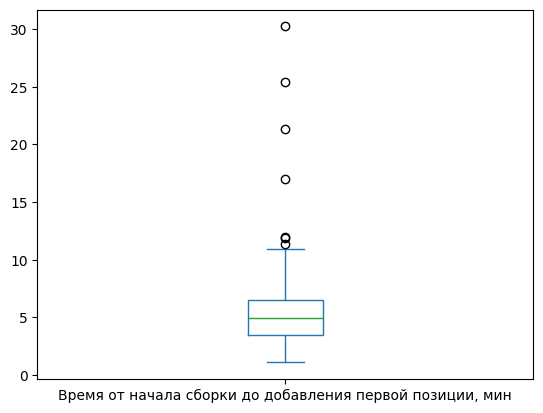

In [31]:
speed_w['Время от начала сборки до добавления первой позиции, мин'].plot(kind='box')


Была сгенерирована новая переменная с категорией сборщика для определения особенностей для двух групп сборщиков: со "стандартным" подходом к сборке (собирают двойной заказ одновременно) и подходом "по очереди" (из двойных заказов собирают сначала один, потом второй). Есть нюанс: так затеряются аномально медленные сборщики - однако это позволит сохранить сборщиков с альтернативной стратегией и учесть нюансы данных. За порог взята скорость в 15 как та, с которой начинаются явные аномалии, судя по графику.

In [32]:
speed_w['Тип старта сборки'] = np.where(speed_w['Время от начала сборки до добавления первой позиции, мин'] > 15, 'Сборка по очереди', 'Стандартный старт')
speed_w.head()

,ID сборщика,Количество заказов,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты + упаковки, мин","Общее время сборки, мин",Скорость сборки общая,Тип старта сборки
0,Сборщик 102,16,2026-01-06,2026-01-10,6.787500,52.009375,1.360417,7.191667,67.348958,3.991049,Стандартный старт
1,Сборщик 106,770,2025-12-28,2026-02-23,1.888636,14.566335,1.101477,4.942178,22.494519,1.227740,Стандартный старт
2,Сборщик 108,11,2026-01-14,2026-01-29,11.975758,31.890909,1.840909,8.971212,54.678788,4.419908,Стандартный старт
3,Сборщик 112,3,2026-02-21,2026-02-21,7.561111,56.672222,2.333333,24.894444,91.461111,5.380065,Стандартный старт
4,Сборщик 116,4,2026-01-23,2026-01-24,11.395833,58.816667,0.712500,11.366667,82.291667,7.655039,Стандартный старт


Также была сгенерирована переменная, позволяющая сравнить сборщиков с целевым значением - 33%. Если существенная часть сборщиков не совершала апсейл за все время измерений, особенно опытных, можно судить о недостаточной информированности о требованиях регламента. По боксплоту видно - большинство сборщиков не делали апсейл за время измерений. Данные разбиты на следующие три категории:


*   Не совершали апсейл вообще
*   До 33% апсейла - видно, что это абсолютное большинство
*   Более 33% апсейла - сборщики, достигающие целевого показателя



In [33]:
def dd_upsell (data):
  conditions = [
      (data['% апсейла от всех успешных звонков'].isna()),
      (data['% апсейла от всех успешных звонков'] > 0.33),
      (data['% апсейла от всех успешных звонков'] > 0)]
  choices = [None, 'Более 33% апсейла', 'До 33% апсейла']
  data['Относительная частота апсейла'] = np.select(conditions, choices, default='Без апсейла')

dd_upsell(calls_w)
dd_upsell(calls_wint)
calls_wint.head()

,ID сборщика,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков,Относительная частота апсейла
0,Сборщик 102,9,8,1,21,12.833333,0.000000,0.875000,0.000000,0.000000,0.000000,0.000000,0.125000,0.000000,0.000000,Без апсейла
1,Сборщик 106,352,282,2,595,334.066667,0.134666,0.707328,0.095041,0.031247,0.008378,0.009092,0.125799,0.023115,0.022393,До 33% апсейла
2,Сборщик 108,4,3,1,5,4.050000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Без апсейла
3,Сборщик 120,5,5,0,7,3.733333,0.600000,0.000000,0.400000,0.200000,0.000000,0.400000,0.000000,0.000000,0.000000,Без апсейла
4,Сборщик 13,1,1,0,1,1.033333,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Без апсейла


## Объединение данных

Задачи исследования связаны со звонками, следовательно, датасет `calls_wint` был взят за основу объединения.

In [34]:
#подстраховка, чтобы ID точно совпало по двум датасетам
calls_wint['ID сборщика'] = calls_wint['ID сборщика'].astype(str).str.strip().str.lower()
speed_w['ID сборщика'] = speed_w['ID сборщика'].astype(str).str.strip().str.lower()

df = calls_wint.merge(speed_w, on='ID сборщика', how='left', validate='one_to_one') #страховка от дубликатов

In [35]:
df.head(10)

,ID сборщика,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,...,Количество заказов,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты + упаковки, мин","Общее время сборки, мин",Скорость сборки общая,Тип старта сборки
0,сборщик 102,9,8,1,21,12.833333,0.000000,0.875000,0.000000,0.000000,...,16.0,2026-01-06,2026-01-10,6.787500,52.009375,1.360417,7.191667,67.348958,3.991049,Стандартный старт
1,сборщик 106,352,282,2,595,334.066667,0.134666,0.707328,0.095041,0.031247,...,770.0,2025-12-28,2026-02-23,1.888636,14.566335,1.101477,4.942178,22.494519,1.227740,Стандартный старт
2,сборщик 108,4,3,1,5,4.050000,0.000000,1.000000,0.000000,0.000000,...,11.0,2026-01-14,2026-01-29,11.975758,31.890909,1.840909,8.971212,54.678788,4.419908,Стандартный старт
3,сборщик 120,5,5,0,7,3.733333,0.600000,0.000000,0.400000,0.200000,...,19.0,2026-01-17,2026-01-18,3.612281,27.185088,0.550877,7.635088,38.983333,2.753470,Стандартный старт
4,сборщик 13,1,1,0,1,1.033333,0.000000,1.000000,0.000000,0.000000,...,4.0,2026-02-11,2026-02-13,9.766667,40.970833,2.175000,5.645833,58.558333,7.555914,Стандартный старт
5,сборщик 130,68,7,5,144,13.200000,0.285714,0.571429,0.285714,0.000000,...,224.0,2026-01-16,2026-02-19,1.086193,26.356473,1.456341,4.994568,33.893756,1.894037,Стандартный старт
6,сборщик 137,1,1,0,1,1.150000,1.000000,0.000000,0.000000,1.000000,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,сборщик 145,36,17,18,22,19.116667,0.506787,0.361991,0.506787,0.000000,...,70.0,2026-01-13,2026-01-21,5.405714,27.788095,1.042976,6.908721,41.145768,2.143554,Стандартный старт
8,сборщик 148,177,29,76,112,33.033333,0.431034,0.339080,0.080460,0.316092,...,452.0,2025-12-28,2026-02-25,2.785669,15.672742,0.885029,7.479991,26.775248,1.532691,Стандартный старт
9,сборщик 153,83,77,1,140,165.383333,0.338120,0.577090,0.042582,0.295538,...,191.0,2025-12-29,2026-02-24,1.767627,27.947039,0.927400,7.756065,38.397881,1.850841,Стандартный старт


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 26 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   ID сборщика                                                180 non-null    object        
 1   Кoл-во заказов                                             180 non-null    int64         
 2   Успешное соединение                                        180 non-null    int64         
 3   Звонка не было                                             180 non-null    int64         
 4   Кол-во попыток звонка                                      180 non-null    int64         
 5   Длительность звонка (разговор)                             180 non-null    float64       
 6   Коммуникационные ошибки                                    180 non-null    float64       
 7   Предложил корректно замену         

# Предобработка данных - объединенные датасеты

При объединении возникло много пропущенных значений и несоответствий:


1.   Переменная `Кол-во заказов` из датасета `calls` стабильно включает меньше заказов, чем в датасете `speed`.
2.   Для многих сборщиков, присутствующих в `calls`, нет записей из датасета `speed`.

Скорее всего, несоответствие в количестве заказов обусловлено тем, что в исходном датасете `calls` отфильтровано большое количество записей. Проверить это можно, сравнив грубые (не отфильтрованные, не считая удаления строки Total) датасеты по количеству заказов - созданные раннее датасеты `speed_copy` и `calls_copy`.

In [37]:
#группировка обоих датасетов по сборщику
raw_check = calls_copy[calls_copy['Дата'] >= speed_copy['min date'].min()] \
    .groupby('ID сборщика')['Кoл-во заказов'].sum().rename('заказы_calls_raw')
speed_check = speed_copy.groupby('ID сборщика')['Количество заказов'].sum().rename('заказы_speed')

# объединение с сохранением всех сборщиков, чтобы зафиксировать аномалии
compare = pd.merge(raw_check, speed_check, left_index=True, right_index=True, how='outer')

# подсчет соотношения
compare['ratio'] = compare['заказы_calls_raw'] / compare['заказы_speed']
display(compare.sort_values('ratio', ascending=False).head(15))
display(compare.sort_values('ratio', ascending=False).tail(10))

,заказы_calls_raw,заказы_speed,ratio
ID сборщика,,,
Сборщик 838,5.0,3.0,1.666667
Сборщик 687,4.0,4.0,1.000000
Сборщик 612,3.0,3.0,1.000000
Сборщик 408,3.0,3.0,1.000000
Сборщик 371,4.0,4.0,1.000000
Сборщик 270,3.0,3.0,1.000000
Сборщик 642,3.0,3.0,1.000000
Сборщик 413,12.0,13.0,0.923077
Сборщик 611,7.0,8.0,0.875000


,заказы_calls_raw,заказы_speed,ratio
ID сборщика,,,
Сборщик 823,1.0,NaN,NaN
Сборщик 824,2.0,NaN,NaN
Сборщик 829,0.0,NaN,NaN
Сборщик 83,1.0,NaN,NaN
Сборщик 831,0.0,NaN,NaN
Сборщик 836,1.0,NaN,NaN
Сборщик 84,1.0,NaN,NaN
Сборщик 842,1.0,NaN,NaN
Сборщик 846,4.0,NaN,NaN




Даже в неотфильтрованном датасете практически не совпадает количество заказов в `speed` и `calls` - значит, дело в специфике данных. Также можно опять видеть сборщиков без записей в датасете со скоростью (и с нулевым количеством заказов - от них уже избавились при фильтрации). Учитывая, что количество заказов стабильно больше в `speed`, в `df` оставлен именно показатель скорости от `speed` как более полный.

За истинное было принято количество заказов из датасета `speed`: оно стабильно больше, чем в `calls`, и не было подвержено фильтрам. В случае NaNов в количестве заказов взято количество из стобца `speed`. Ненужный столбец удален.

In [38]:
# сохранение количества заказов аномального сборщика из raw таблицы
df.loc[df['ID сборщика'] == 'сборщик 838', 'Количество заказов'] = 5
df['Количество заказов'] = df['Количество заказов'].fillna(df['Кoл-во заказов'])
df = df.drop(columns='Кoл-во заказов')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 25 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   ID сборщика                                                180 non-null    object        
 1   Успешное соединение                                        180 non-null    int64         
 2   Звонка не было                                             180 non-null    int64         
 3   Кол-во попыток звонка                                      180 non-null    int64         
 4   Длительность звонка (разговор)                             180 non-null    float64       
 5   Коммуникационные ошибки                                    180 non-null    float64       
 6   Предложил корректно замену                                 180 non-null    float64       
 7   Сообщил об отсутствии, не предложил

Анализ пропущенных значений в объединенном датасете:

In [39]:
df[df.isna().any(axis=1)]

,ID сборщика,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,...,Количество заказов,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты + упаковки, мин","Общее время сборки, мин",Скорость сборки общая,Тип старта сборки
6,сборщик 137,1,0,1,1.150000,1.00,0.00,0.00,1.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,сборщик 204,1,0,2,0.950000,1.00,0.00,1.00,0.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,сборщик 210,1,0,2,1.716667,1.00,0.00,1.00,0.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,сборщик 213,1,0,1,1.383333,1.00,0.00,0.00,1.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,сборщик 230,1,0,1,0.850000,1.00,0.00,0.00,1.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,сборщик 24,1,0,1,1.133333,0.00,1.00,0.00,0.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,сборщик 241,1,0,1,0.650000,1.00,0.00,1.00,0.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,сборщик 250,1,0,2,0.916667,0.00,1.00,0.00,0.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,сборщик 277,1,0,1,4.650000,1.00,0.00,1.00,0.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,сборщик 290,1,0,3,0.933333,1.00,0.00,0.00,1.0,0.0,...,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Для большинства строк не более 1 успешного соединения и не более 1-2 заказов за все время - аргумент в пользу того, что этими строками можно пренебречь, это новички или сборщики на обучении. К тому же, отсутствие информации для датасета `speed` аннулирует необходимость этих строк для датасета.

Проверка того, совпадают ли ID сборщиков в обоих оригинальных датасетах (позволит выявить ошибки форматирования):

In [40]:
calls_ids = set(calls_wint['ID сборщика'].unique())
speed_ids = set(speed_w['ID сборщика'].unique())

only_in_calls = calls_ids - speed_ids #остаются только значения, уникальные для конкретного датасета
only_in_speed = speed_ids - calls_ids
print("ID, которые есть ТОЛЬКО в звонках (calls):")
print(sorted(list(only_in_calls)))
print("ID, которые есть ТОЛЬКО в скорости (speed):")
print(sorted(list(only_in_speed)))

ID, которые есть ТОЛЬКО в звонках (calls):
['сборщик 137', 'сборщик 204', 'сборщик 210', 'сборщик 213', 'сборщик 230', 'сборщик 24', 'сборщик 241', 'сборщик 250', 'сборщик 277', 'сборщик 290', 'сборщик 299', 'сборщик 308', 'сборщик 326', 'сборщик 393', 'сборщик 400', 'сборщик 411', 'сборщик 412', 'сборщик 451', 'сборщик 469', 'сборщик 471', 'сборщик 477', 'сборщик 481', 'сборщик 505', 'сборщик 512', 'сборщик 542', 'сборщик 559', 'сборщик 562', 'сборщик 583', 'сборщик 600', 'сборщик 609', 'сборщик 643', 'сборщик 736', 'сборщик 740', 'сборщик 757', 'сборщик 765', 'сборщик 777', 'сборщик 798', 'сборщик 8', 'сборщик 824', 'сборщик 84', 'сборщик 842', 'сборщик 846']
ID, которые есть ТОЛЬКО в скорости (speed):
['сборщик 112', 'сборщик 116', 'сборщик 199', 'сборщик 207', 'сборщик 303', 'сборщик 390', 'сборщик 443', 'сборщик 444', 'сборщик 448', 'сборщик 503', 'сборщик 516', 'сборщик 538', 'сборщик 578', 'сборщик 623', 'сборщик 625', 'сборщик 635', 'сборщик 676', 'сборщик 702', 'сборщик 730', 

Повторяющихся значений нет - дело не в форматировании. Значит, проблема в бизнес-логике данных: у сборщиков, совершавших мало звонков, может быть один-два заказа, а такие обычно не попадают в статистику по скорости.

In [41]:
df = df.dropna(subset='min date')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138 entries, 0 to 179
Data columns (total 25 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   ID сборщика                                                138 non-null    object        
 1   Успешное соединение                                        138 non-null    int64         
 2   Звонка не было                                             138 non-null    int64         
 3   Кол-во попыток звонка                                      138 non-null    int64         
 4   Длительность звонка (разговор)                             138 non-null    float64       
 5   Коммуникационные ошибки                                    138 non-null    float64       
 6   Предложил корректно замену                                 138 non-null    float64       
 7   Сообщил об отсутствии, не предложил заме

По итогам обработки пропусков удалены строки объединенного датафрейма с отсутствующими данными скорости (42 строки).

## Работа с аномалиями

Посмотрим на распредление данных с помощью гистограмм и графиков с усами.

### Аномалии в датасете df

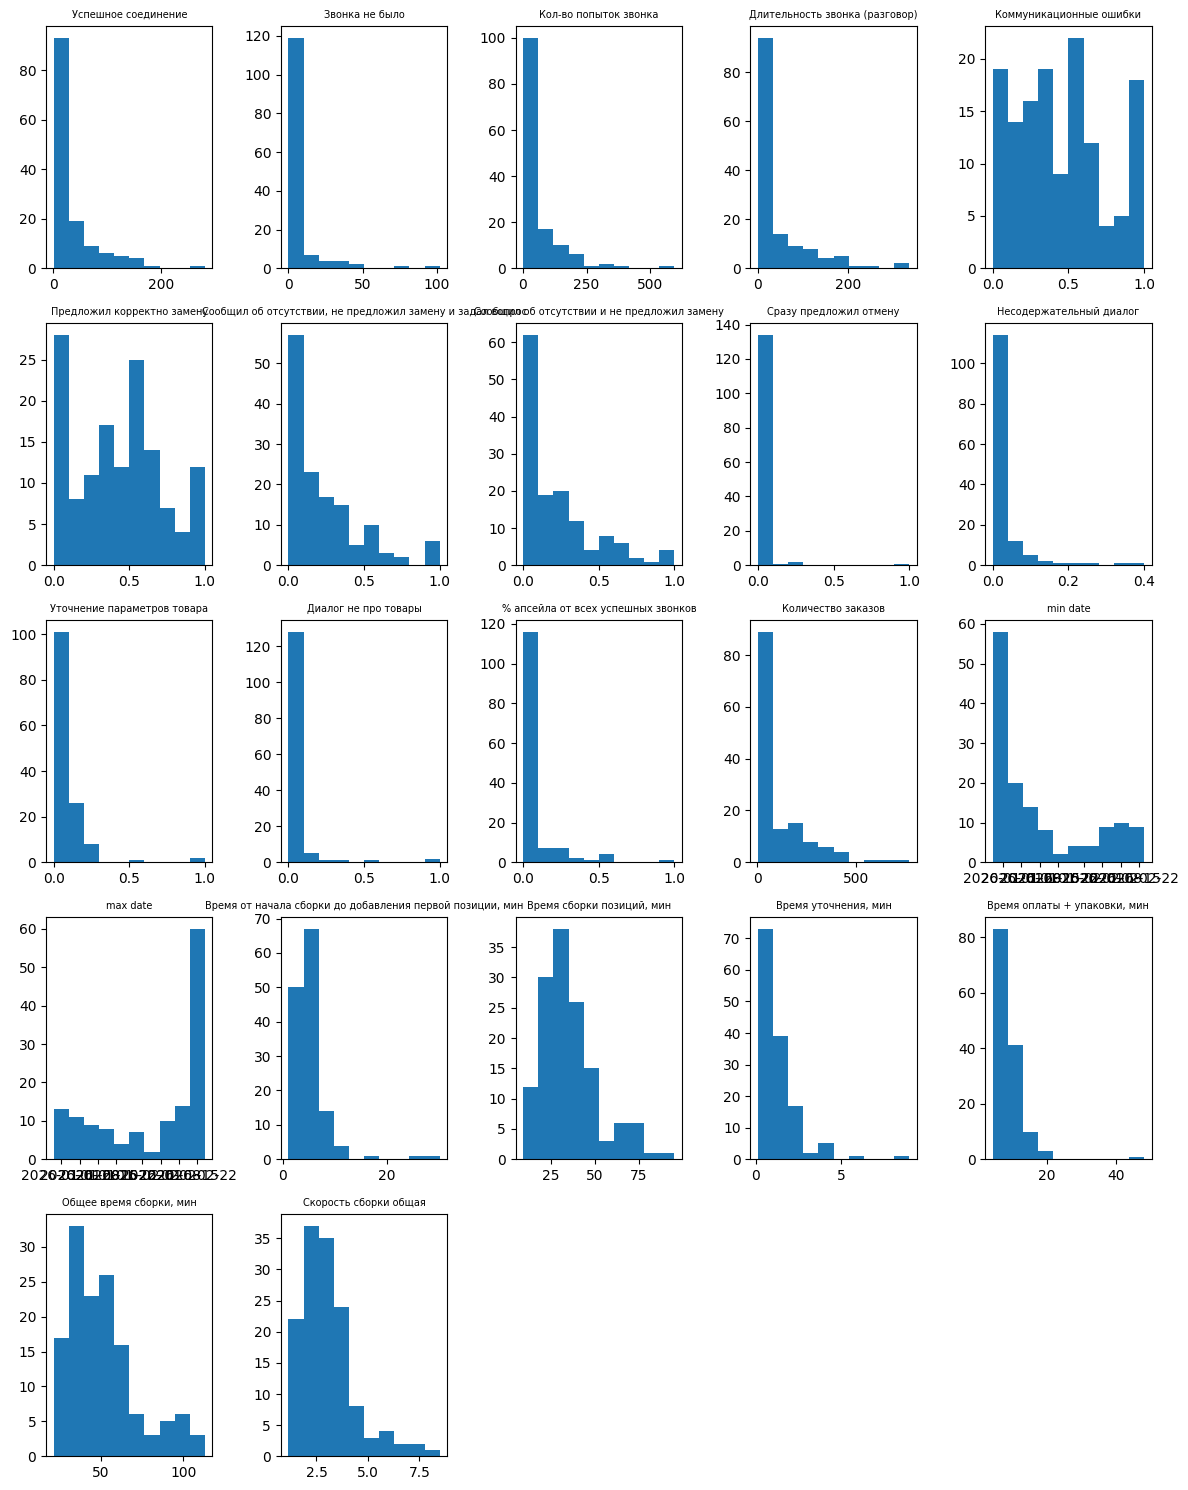

In [42]:
plt.rc('axes', titlesize=7)
df.hist(figsize=(12, 15), grid=False)
plt.tight_layout()
plt.show()

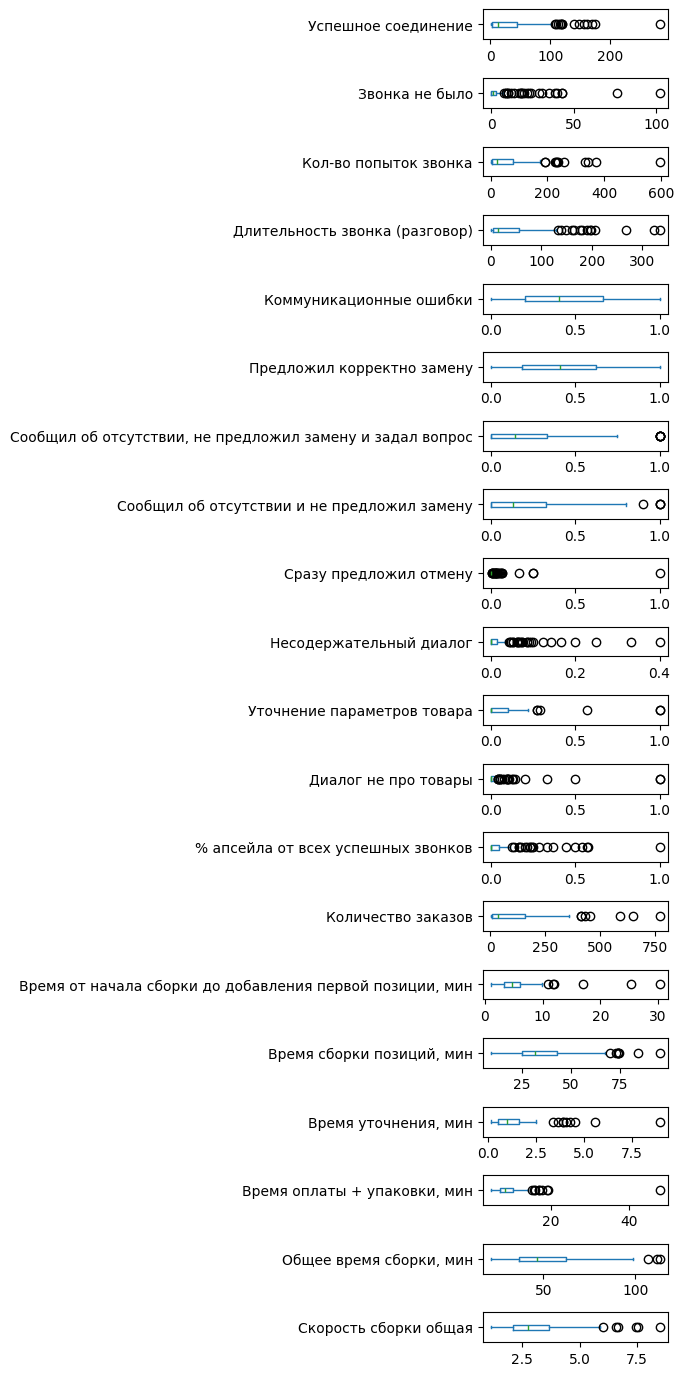

In [43]:
plt.rc('axes', titlesize=5)
df.plot(kind='box', vert=False, subplots=True, layout=(22, 1), figsize=(7, 15), sharex=False)
plt.tight_layout()
plt.show()

Большинство данных распределено одинаково: наибольшее количество данных сконцентрировано в начале шкалы, с медианой где-то в районе 10-25% от всей шкалы, с длинным "хвостом" распределения, соответствующим выбросам - большим заказам (`Общее время сборки, мин`), активно работающим сборщикам (`Количество заказов`) или долгим звонкам при особо сложных заказах (`Время уточнения, мин`). В большинстве своем графики отражают специфику переменных - аномальные "хвосты" - отклонения, объяснимые регулярно возникающими сложностями. Все процентные значения, как и должны, распределены от 0 до 1 (или меньше 1).

Следует отметить следующие нюансы распределений:
- `min date` и `max date` сконцентрированы у наибольших и наименьших значений - это нормально, большинство сборщиков работали равномерно с первого до последнего дня измерений;
- Аномальные значения переменной `Время от начала сборки до добавления первой позиции, мин` (минимально допустимая по регламенту - 2 минуты) уже решено сохранять для проверки альтернативных стратегий сборки;
- Аномальные значения `Время оплаты + упаковки, мин` (минимально допустимая - 5 минут), `Скорость сборки общая` (минимально допустимая - 3), `Время уточнения, мин` - могут серьезно исказить показатели. По боксплотам видно, что аномальные данные (длинные хвосты распределений) органически присутствуют в данных, это подтверждается и данными:


In [44]:
df[df['Время оплаты + упаковки, мин'] > 15].head()

,ID сборщика,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,...,Количество заказов,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты + упаковки, мин","Общее время сборки, мин",Скорость сборки общая,Тип старта сборки
57,сборщик 340,6,1,13,6.416667,0.750000,0.000000,0.500000,0.250000,0.000000,...,9.0,2026-01-13,2026-01-15,11.875926,67.027778,2.253704,15.838889,96.996296,6.663868,Стандартный старт
85,сборщик 460,5,0,10,4.900000,0.200000,0.600000,0.000000,0.200000,0.000000,...,7.0,2026-02-11,2026-02-22,9.326190,70.178571,0.980952,15.690476,96.176190,3.852983,Стандартный старт
104,сборщик 524,36,10,50,38.566667,0.392361,0.373843,0.327546,0.064815,0.000000,...,116.0,2025-12-28,2026-02-20,2.204023,46.149138,0.600718,47.972126,96.926006,2.128299,Стандартный старт
110,сборщик 545,1,1,1,1.166667,0.000000,1.000000,0.000000,0.000000,0.000000,...,4.0,2026-01-10,2026-01-10,7.400000,43.229167,2.087500,18.866667,71.583333,2.863333,Стандартный старт
114,сборщик 566,75,2,110,128.200000,0.204297,0.504642,0.019259,0.162815,0.022222,...,270.0,2025-12-28,2026-02-24,2.644427,20.432257,1.920137,19.152531,42.621661,2.113198,Стандартный старт


In [45]:
df[df['Скорость сборки общая'] > 6].head()

,ID сборщика,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,...,Количество заказов,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты + упаковки, мин","Общее время сборки, мин",Скорость сборки общая,Тип старта сборки
4,сборщик 13,1,0,1,1.033333,0.000000,1.000000,0.0,0.000000,0.0,...,4.0,2026-02-11,2026-02-13,9.766667,40.970833,2.175000,5.645833,58.558333,7.555914,Стандартный старт
57,сборщик 340,6,1,13,6.416667,0.750000,0.000000,0.5,0.250000,0.0,...,9.0,2026-01-13,2026-01-15,11.875926,67.027778,2.253704,15.838889,96.996296,6.663868,Стандартный старт
72,сборщик 408,3,0,5,4.533333,0.333333,0.333333,0.0,0.333333,0.0,...,3.0,2026-01-02,2026-01-02,6.477778,73.172222,1.583333,11.022222,92.255556,7.480180,Стандартный старт
91,сборщик 472,1,0,2,1.533333,0.000000,1.000000,0.0,0.000000,0.0,...,4.0,2026-02-24,2026-02-24,5.425000,9.604167,1.411111,7.950000,22.662500,6.043333,Стандартный старт
159,сборщик 776,2,0,4,3.416667,0.000000,0.000000,0.0,0.000000,0.0,...,5.0,2026-02-12,2026-02-13,9.220000,84.506667,1.386667,16.836667,111.950000,6.585294,Стандартный старт


In [46]:
df[df['Время уточнения, мин'] > 6].head()

,ID сборщика,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,...,Количество заказов,min date,max date,"Время от начала сборки до добавления первой позиции, мин","Время сборки позиций, мин","Время уточнения, мин","Время оплаты + упаковки, мин","Общее время сборки, мин",Скорость сборки общая,Тип старта сборки
22,сборщик 202,1,0,1,0.683333,0.0,0.0,0.0,0.0,0.0,...,3.0,2026-02-18,2026-02-18,6.438889,35.766667,8.966667,11.411111,62.583333,4.579268,Стандартный старт


Сборщики с аномальной скоростью сборки и временем оплаты / упаковки - абсолютно реальные, а в случае со временем оплаты - еще и опытные (более 100 заказов за период измерений). Полное удаление строк исказит статистику, строки оставлены, но время оплаты / упаковки для сборщика 524 удалено - оно в разы превышает регламент и гарантирует искажения.

In [47]:
df.loc[df['ID сборщика'] == 'сборщик 524', 'Время оплаты + упаковки, мин'] = np.nan

### Аномалии в датасете calls_w

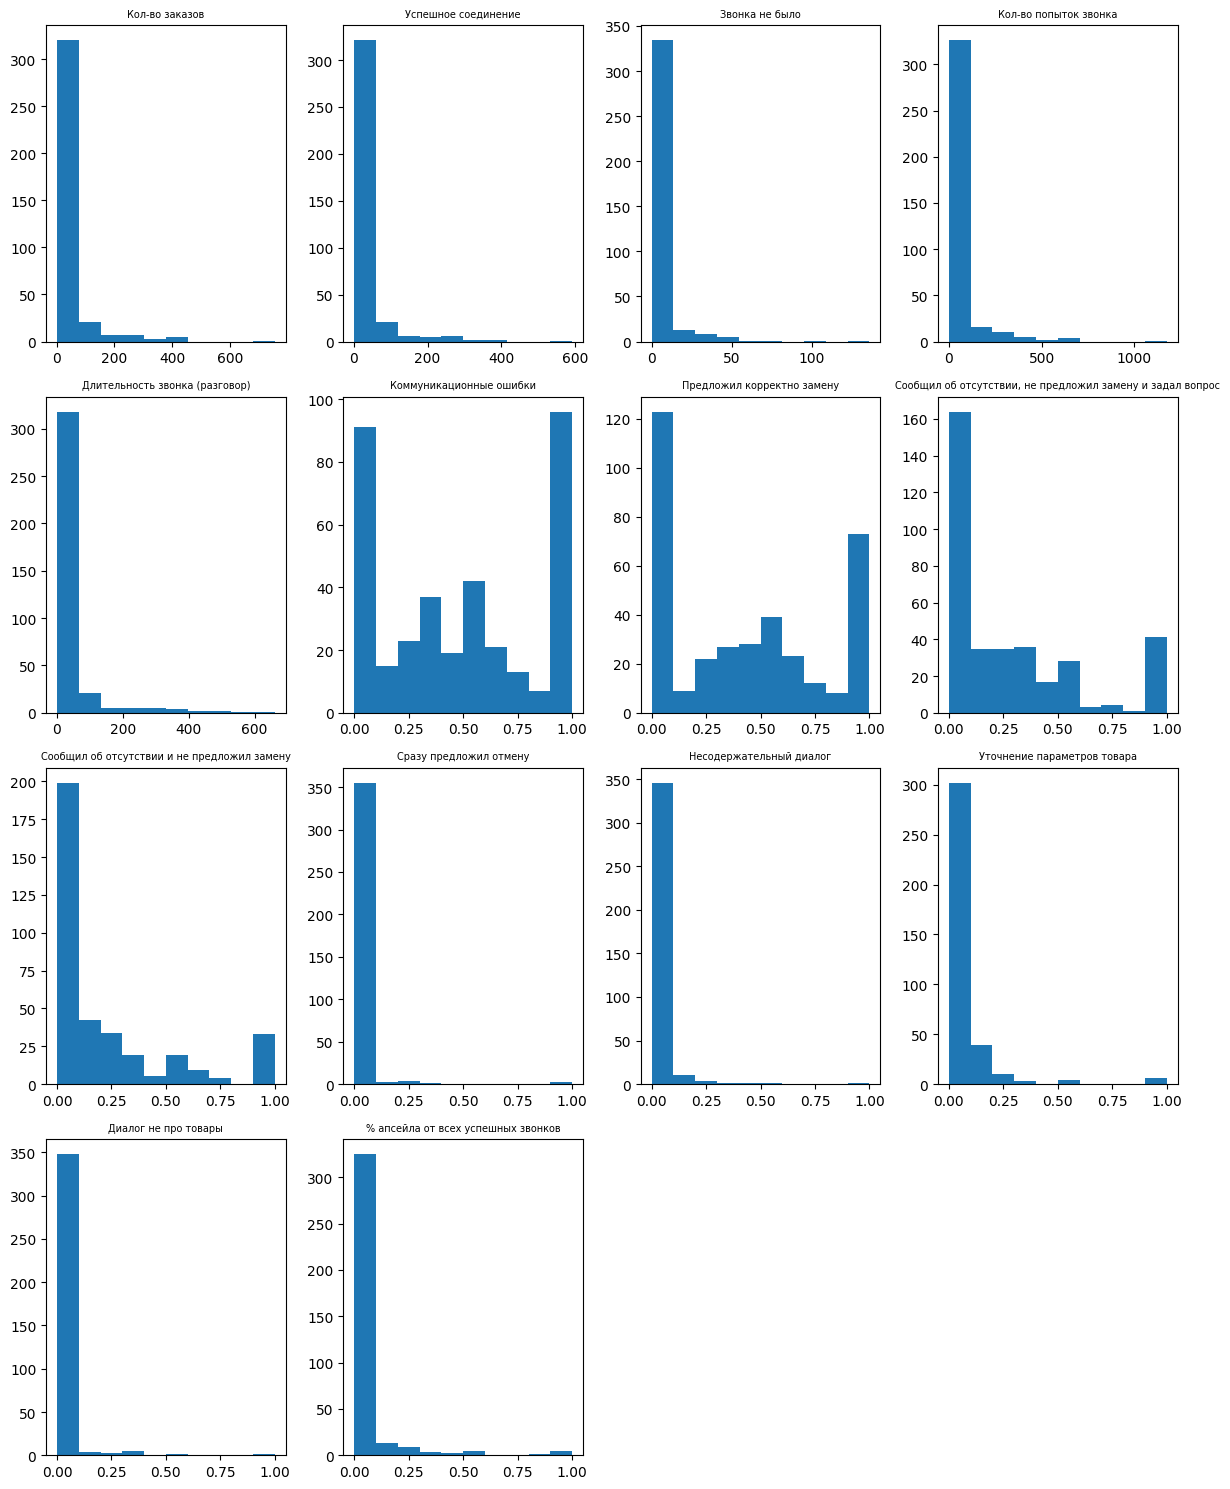

In [48]:
plt.rc('axes', titlesize=7)
calls_w.hist(figsize=(12, 15), grid=False)
plt.tight_layout()
plt.show()

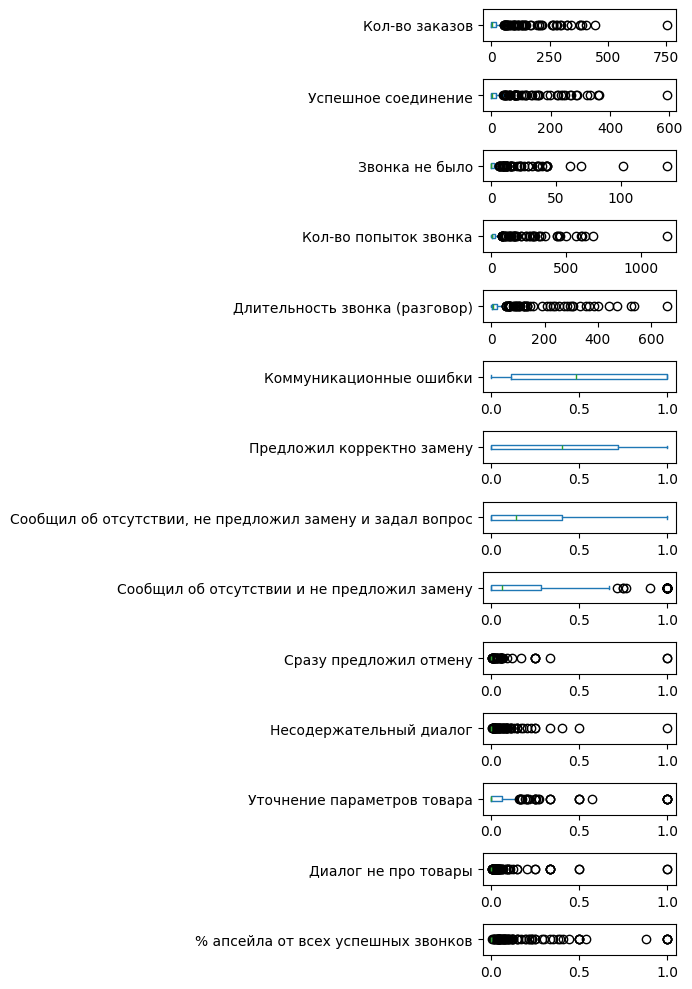

In [49]:
plt.rc('axes', titlesize=5)
calls_w.plot(kind='box', vert=False, subplots=True, layout=(14, 1), figsize=(7, 10), sharex=False)
plt.tight_layout()
plt.show()

Для датасета `calls_w` аномалий не выявлено - все переменные имеют пик около нуля и хвост; дробные - строго в диапазоне допустимых значений; переменные с количеством заказов, попыток звонка и отсутствия попыток звонка достигают больших значений, но это соответствует наиболее активным сборщикам (хотя в случае сборщика 334 - недобросовестным).

In [50]:
calls_w[calls_w['Звонка не было'] > 100]

,ID сборщика,Кoл-во заказов,Успешное соединение,Звонка не было,Кол-во попыток звонка,Длительность звонка (разговор),Коммуникационные ошибки,Предложил корректно замену,"Сообщил об отсутствии, не предложил замену и задал вопрос",Сообщил об отсутствии и не предложил замену,Сразу предложил отмену,Несодержательный диалог,Уточнение параметров товара,Диалог не про товары,% апсейла от всех успешных звонков,Относительная частота апсейла
17,Сборщик 148,380,86,136,269,84.266667,0.495709,0.387182,0.088178,0.395903,0.011628,0.000000,0.082226,0.034884,0.116279,До 33% апсейла
112,Сборщик 334,141,28,102,49,53.466667,0.553571,0.253571,0.321429,0.196429,0.035714,0.035714,0.121429,0.035714,0.042857,До 33% апсейла


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138 entries, 0 to 179
Data columns (total 25 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   ID сборщика                                                138 non-null    object        
 1   Успешное соединение                                        138 non-null    int64         
 2   Звонка не было                                             138 non-null    int64         
 3   Кол-во попыток звонка                                      138 non-null    int64         
 4   Длительность звонка (разговор)                             138 non-null    float64       
 5   Коммуникационные ошибки                                    138 non-null    float64       
 6   Предложил корректно замену                                 138 non-null    float64       
 7   Сообщил об отсутствии, не предложил заме

In [52]:
calls_w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 16 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   ID сборщика                                                364 non-null    object 
 1   Кoл-во заказов                                             364 non-null    int64  
 2   Успешное соединение                                        364 non-null    int64  
 3   Звонка не было                                             364 non-null    int64  
 4   Кол-во попыток звонка                                      364 non-null    int64  
 5   Длительность звонка (разговор)                             364 non-null    float64
 6   Коммуникационные ошибки                                    364 non-null    float64
 7   Предложил корректно замену                                 364 non-null    float64
 8   Сообщил об

В итоге предобработки данных созданы два датасета:


*   `calls_w`, содержащие информацию по звонкам за время измерений с 27 октября - 364 записи;
*   `df`, содержащий информацию по скорости и звонкам с 28 декабря для 138 сборщиков.



## Сохранение предобработанных данных

In [53]:
df.to_csv('merged_data.csv', index=False)
calls_w.to_csv('calls_data.csv', index=False)
# ---------------------------------------------------------
# Код ниже закомментирован для удобства ревьюера,
# чтобы избежать автоматического скачивания файла на ваше устройство.
# ---------------------------------------------------------
#files.download('merged_data.csv')
#files.download('calls_data.csv')